In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
human_cap = pd.read_csv('../data/Zambia_HumanCapital/human_capital.csv')

In [3]:
human_cap_clean, human_cap_lookup = clean_wb_wide(human_cap, drop_top_rows=0)

In [4]:
print(
    make_lookup_latex(human_cap_lookup,
                      caption='World Bank indicators used in Capital Accumulation (Zambia)',
                      label='tab:ca_indicator_list')
)

\begin{table}
\caption{World Bank indicators used in Capital Accumulation (Zambia)}
\label{tab:ca_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
SP.URB.TOTL & Urban population \\
SP.URB.TOTL.IN.ZS & Urban population (\% of total population) \\
SP.URB.GROW & Urban population growth (annual \%) \\
DT.DOD.DECT.GN.ZS & External debt stocks (\% of GNI) \\
DT.DOD.DLXF.CD & External debt stocks, long-term (DOD, current US\$) \\
SE.SEC.ENRR & School enrollment, secondary (\% gross) \\
SE.ENR.SECO.FM.ZS & School enrollment, secondary (gross), gender parity index (GPI) \\
SE.SEC.ENRR.FE & School enrollment, secondary, female (\% gross) \\
SE.SEC.ENRR.MA & School enrollment, secondary, male (\% gross) \\
SE.TER.ENRR & School enrollment, tertiary (\% gross) \\
SE.ENR.TERT.FM.ZS & School enrollment, tertiary (gross), gender parity index (GPI) \\
SE.TER.ENRR.FE & School enrollment, tertiary, female (\% gross) \\
SE.TER.ENRR.MA & School enrollment, tertiary, 

# Check data availability by series and year

In [5]:
hc_summary = summary_wb(human_cap_clean, human_cap_lookup)
hc_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,SP.URB.TOTL,Urban population,0.000000,65,1960,2024
1,SP.URB.TOTL.IN.ZS,Urban population (% of total population),0.000000,65,1960,2024
2,SP.URB.GROW,Urban population growth (annual %),1.538462,64,1961,2024
3,DT.DOD.DECT.GN.ZS,External debt stocks (% of GNI),15.384615,55,1970,2024
4,DT.DOD.DLXF.CD,"External debt stocks, long-term (DOD, current ...",15.384615,55,1970,2024
5,SE.SEC.ENRR,"School enrollment, secondary (% gross)",69.230769,20,1970,2024
6,SE.ENR.SECO.FM.ZS,"School enrollment, secondary (gross), gender p...",86.153846,9,1970,1988
7,SE.SEC.ENRR.FE,"School enrollment, secondary, female (% gross)",84.615385,10,1970,2024
8,SE.SEC.ENRR.MA,"School enrollment, secondary, male (% gross)",84.615385,10,1970,2024
9,SE.TER.ENRR,"School enrollment, tertiary (% gross)",69.230769,20,1970,2012


In [6]:
print(
    make_summary_latex(hc_summary,
                       caption='Data availability of Capital Accumulation (Zambia)',
                       label='tab:ca_data_availability')
)

\begin{table}
\caption{Data availability of Capital Accumulation (Zambia)}
\label{tab:ca_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
SP.URB.TOTL & 0.00 & 65 & 1960 & 2024 \\
SP.URB.TOTL.IN.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.URB.GROW & 1.50 & 64 & 1961 & 2024 \\
DT.DOD.DECT.GN.ZS & 15.40 & 55 & 1970 & 2024 \\
DT.DOD.DLXF.CD & 15.40 & 55 & 1970 & 2024 \\
SE.SEC.ENRR & 69.20 & 20 & 1970 & 2024 \\
SE.ENR.SECO.FM.ZS & 86.20 & 9 & 1970 & 1988 \\
SE.SEC.ENRR.FE & 84.60 & 10 & 1970 & 2024 \\
SE.SEC.ENRR.MA & 84.60 & 10 & 1970 & 2024 \\
SE.TER.ENRR & 69.20 & 20 & 1970 & 2012 \\
SE.ENR.TERT.FM.ZS & 81.50 & 12 & 1970 & 2012 \\
SE.TER.ENRR.FE & 81.50 & 12 & 1970 & 2012 \\
SE.TER.ENRR.MA & 81.50 & 12 & 1970 & 2012 \\
SE.PRM.ENRR.FE & 36.90 & 41 & 1970 & 2024 \\
SE.PRM.ENRR.MA & 36.90 & 41 & 1970 & 2024 \\
SE.PRM.ENRR & 30.80 & 45 & 1970 & 2024 \\
SE.ENR.PRIM.FM.ZS & 38.50 & 40 & 1970 & 2017 \\
SE.PRE.ENRR &

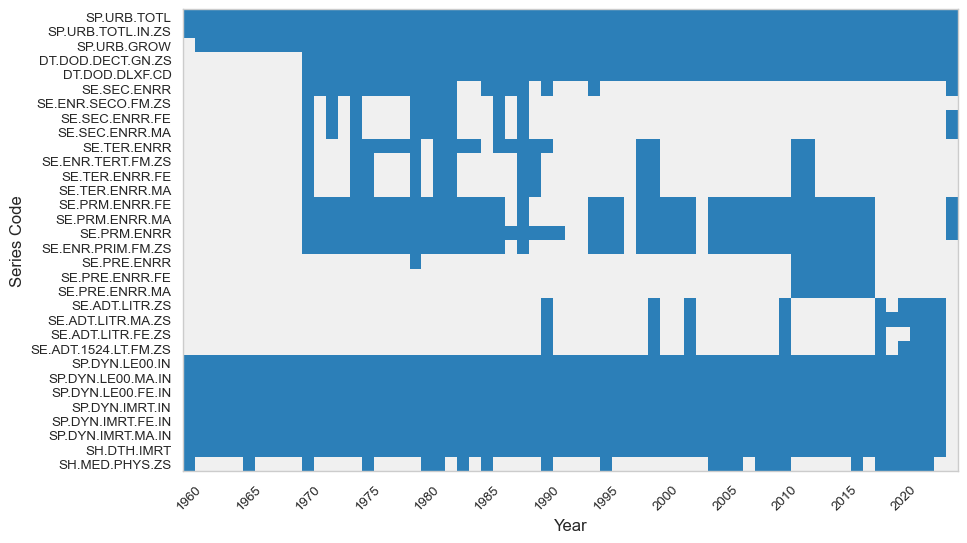

In [7]:
availability, fig, ax = plot_missing_heatmap(
    human_cap_clean,
    lookup=human_cap_lookup
)

fig.savefig(
    "../figures/human_capital/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Data Visualization

In [8]:
human_cap_lookup

,Series Code,Series Name
0,SP.URB.TOTL,Urban population
1,SP.URB.TOTL.IN.ZS,Urban population (% of total population)
2,SP.URB.GROW,Urban population growth (annual %)
3,DT.DOD.DECT.GN.ZS,External debt stocks (% of GNI)
4,DT.DOD.DLXF.CD,"External debt stocks, long-term (DOD, current ..."
5,SE.SEC.ENRR,"School enrollment, secondary (% gross)"
6,SE.ENR.SECO.FM.ZS,"School enrollment, secondary (gross), gender p..."
7,SE.SEC.ENRR.FE,"School enrollment, secondary, female (% gross)"
8,SE.SEC.ENRR.MA,"School enrollment, secondary, male (% gross)"
9,SE.TER.ENRR,"School enrollment, tertiary (% gross)"


## Education

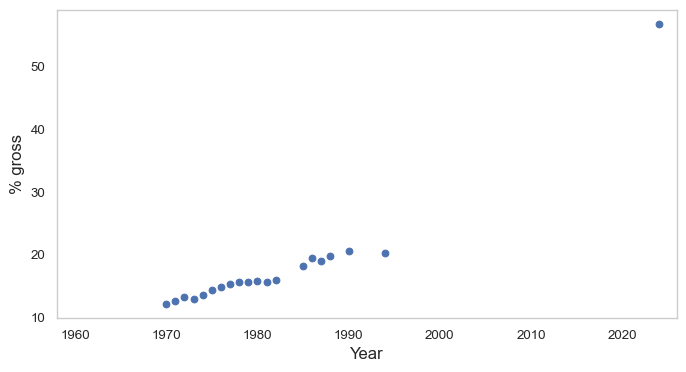

In [11]:
# gross secondary education
df = human_cap_clean.dropna(subset=['SE.SEC.ENRR'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['Year'], df['SE.SEC.ENRR'])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% gross', fontsize=12)

# set range
# ax.set_ylim(700, 4000)
ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/human_capital/gross_second_edu.pdf",
    format="pdf",
    bbox_inches="tight"
)

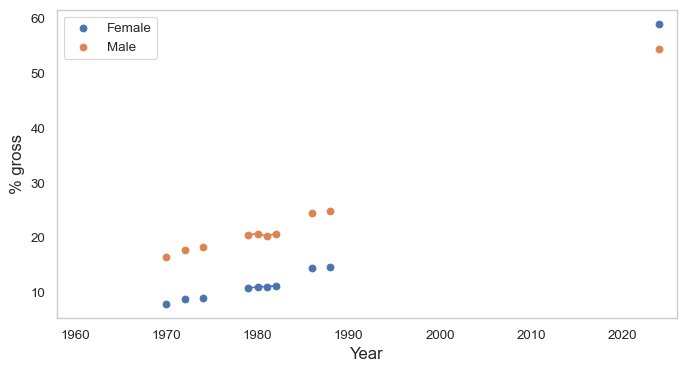

In [29]:
# gross secondary education gender
df = human_cap_clean

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df['Year'], df['SE.SEC.ENRR.FE'])
ax.plot(df['Year'], df['SE.SEC.ENRR.MA'])

ax.scatter(df['Year'], df['SE.SEC.ENRR.FE'], label='Female')
ax.scatter(df['Year'], df['SE.SEC.ENRR.MA'], label='Male')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% gross', fontsize=12)
ax.legend()

# set range
# ax.set_ylim(700, 4000)
ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/human_capital/gross_second_edu_gender.pdf",
    format="pdf",
    bbox_inches="tight"
)

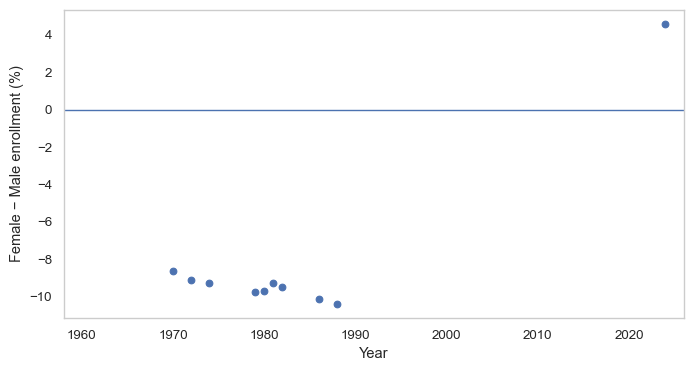

In [33]:
# second edu gender gap
df['gap'] = df['SE.SEC.ENRR.FE'] - df['SE.SEC.ENRR.MA']

fig, ax = plt.subplots(figsize=(8,4))

ax.scatter(df['Year'], df['gap'])

ax.set_xlim(1958, 2026)
ax.axhline(0, linewidth=1)
ax.grid(False)

ax.set_xlabel('Year')
ax.set_ylabel('Female − Male enrollment (%)')

fig.savefig(
    "../figures/human_capital/gross_second_edu_gender_gap.pdf",
    format="pdf",
    bbox_inches="tight"
)